# Guided Numeric Exploration — Banking Transactions Dataset
_Synthetic multi-table banking warehouse: customers, loans, tickets, and sampled payments/fraud_

***

**Programming Language:** Python in the Jupyter Notebook Environment

**Dataset:** [vivekmali1436/banking-transactions-dataset](https://www.kaggle.com/datasets/vivekmali1436/banking-transactions-dataset)

**Style counterpart:** [Guided Numeric and Text Exploration — E-Commerce](https://www.kaggle.com/code/nicapotato/guided-numeric-and-text-exploration-e-commerce)

**Code Navigation:** <br>
In the code, text after hashtags (`#`) are supportive explanations, not executed as code.

***


# Tables of Content:

**1. [Introduction](#Introduction)** <br>
**2. [Setup and Data Peek](#Setup)** <br>
**3. [Customers, Accounts, Credit](#Customers)** <br>
**4. [Loans and Late Payments](#Loans)** <br>
**5. [Support Tickets](#Tickets)** <br>
**6. [Sampled Transactions & Card Fraud](#Fraud)** <br>
**7. [What It Means — Working Synthesis](#Synthesis)** <br>

# **1. Introduction:** <a id="Introduction"></a> <br>
A **synthetic** banking dataset (CC-BY-SA-4.0) with relational tables for customers, accounts, cards, loans, payments, support tickets, branches/employees, plus large `transactions` (~2M) and `card_transactions` (~3M) fact tables.

I load full dimension / mid-size tables and **sample** the huge transaction facts for plotting, with one chunked pass for global fraud rates — so the notebook stays executable locally without holding millions of rows in every cell. Nothing here is a real bank's ledger.


# **2. Setup and Data Peek:** <a id="Setup"></a>


In [1]:
# General
import numpy as np
import pandas as pd
from pathlib import Path

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Scientific / modeling helpers
from IPython.display import display
from scipy import stats
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.decomposition import PCA

import kagglehub

# Set Plot Theme (same family as the e-commerce guided notebook)
sns.set_palette([
    "#30a2da",
    "#fc4f30",
    "#e5ae38",
    "#6d904f",
    "#8b8b8b",
])
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (11, 5)

# Warnings
import warnings
warnings.filterwarnings("ignore")

# Wide table inspection in Jupyter cell outputs
pd.set_option("display.max_columns", 999)
pd.set_option("display.width", 220)


/Users/nicapotato/Documents/repo/project/KaggleNotebooks/eda/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


**Code Explanation and Reasoning:** <br>
These packages fall into three buckets: *General*, *Visualization*, and *Scientific / modeling helpers*.

`pandas` / `numpy` hold the table; `matplotlib` / `seaborn` do the graphics; `scipy` and `sklearn` support light associational checks (correlations, RandomForest importances, PCA), not a production model. `kagglehub` resolves files both on Kaggle (`/kaggle/input/...`) and locally.

The five-color palette matches the guided e-commerce notebook so sequential plots feel like one continuous exploration.


In [2]:
# Read and Peak at Data
KAGGLE_SLUG = "vivekmali1436/banking-transactions-dataset"
DIM_FILES = [
    "customers.csv", "accounts.csv", "branches.csv", "cards.csv",
    "employees.csv", "loans.csv", "loan_payments.csv", "support_tickets.csv",
]
TX_SAMPLE_N = 200_000
CARD_SAMPLE_N = 250_000


def resolve_dataset_root() -> Path:
    kaggle_root = Path("/kaggle/input")
    if kaggle_root.exists():
        hits = list(kaggle_root.rglob("customers.csv"))
        assert hits, "customers.csv not under /kaggle/input"
        return hits[0].parent
    local_dir = Path("data") / "banking-transactions-dataset"
    if (local_dir / "customers.csv").exists():
        return local_dir
    root = Path(kagglehub.dataset_download(KAGGLE_SLUG))
    hits = list(root.rglob("customers.csv"))
    assert hits, f"customers.csv not under {root}"
    return hits[0].parent


root = resolve_dataset_root()
print("Dataset root:", root)
for name in DIM_FILES:
    assert (root / name).exists() or list(root.rglob(name)), f"missing {name}"

def load_csv(name: str, **kwargs) -> pd.DataFrame:
    hits = list(Path(root).rglob(name))
    assert hits, name
    return pd.read_csv(hits[0], low_memory=False, **kwargs)

customers = load_csv("customers.csv")
accounts = load_csv("accounts.csv")
branches = load_csv("branches.csv")
cards = load_csv("cards.csv")
loans = load_csv("loans.csv")
loan_payments = load_csv("loan_payments.csv")
tickets = load_csv("support_tickets.csv")

assert customers["customer_id"].is_unique
assert accounts["account_id"].is_unique
assert accounts["customer_id"].isin(customers["customer_id"]).all()
assert loans["customer_id"].isin(customers["customer_id"]).all()

print("customers", customers.shape, "| accounts", accounts.shape, "| loans", loans.shape)
print("loan_payments", loan_payments.shape, "| tickets", tickets.shape, "| cards", cards.shape)
print("branches", branches.shape)
display(customers.sample(3, random_state=7))



  0%|          | 0.00/89.4M [00:00<?, ?B/s]


  1%|          | 1.00M/89.4M [00:00<00:48, 1.92MB/s]


  2%|▏         | 2.00M/89.4M [00:01<00:43, 2.09MB/s]


  3%|▎         | 3.00M/89.4M [00:01<00:33, 2.72MB/s]


  4%|▍         | 4.00M/89.4M [00:01<00:29, 3.08MB/s]

...


100%|██████████| 89.4M/89.4M [00:26<00:00, 3.60MB/s]

Extracting files...


Dataset root: /Users/nicapotato/.cache/kagglehub/datasets/vivekmali1436/banking-transactions-dataset/versions/1


customers (60000, 12) | accounts (95000, 7) | loans (22000, 9)
loan_payments (600000, 7) | tickets (25000, 7) | cards (65000, 8)
branches (150, 6)


,customer_id,name,gender,date_of_birth,city,state,phone,email,occupation,annual_income,join_date,credit_score
25170,25171,Rahul Jones,Male,1953-04-21,Mumbai,Maharashtra,9774505550,customer25170@mailbank.com,Salaried - Private,1728835,2020-01-25,686
10935,10936,John Gupta,Female,1966-03-28,Mumbai,Maharashtra,9294222614,customer10935@mailbank.com,Salaried - Private,2629783,2016-02-27,444
43596,43597,Sanjay Chopra,Male,1963-03-13,Bhopal,Madhya Pradesh,9384804646,customer43596@mailbank.com,Salaried - Government,1243053,2013-08-19,462


**Code Explanation and Reasoning:** <br>
Dimension tables load fully with key asserts (`customer_id` uniqueness, FK membership). Large transaction files are deferred to a later sample/chunk section so setup stays light.


In [3]:
# Schema peek across core tables
for name, frame in [
    ("customers", customers), ("accounts", accounts), ("loans", loans),
    ("loan_payments", loan_payments), ("tickets", tickets), ("cards", cards),
]:
    print(f"\n{name}: {frame.shape[0]:,} × {frame.shape[1]}")
    print(" nulls:", int(frame.isnull().sum().sum()), "| columns:", list(frame.columns))



customers: 60,000 × 12
 nulls: 0 | columns: ['customer_id', 'name', 'gender', 'date_of_birth', 'city', 'state', 'phone', 'email', 'occupation', 'annual_income', 'join_date', 'credit_score']

accounts: 95,000 × 7
 nulls: 0 | columns: ['account_id', 'customer_id', 'branch_id', 'account_type', 'balance', 'open_date', 'status']

loans: 22,000 × 9
 nulls: 0 | columns: ['loan_id', 'customer_id', 'branch_id', 'loan_type', 'loan_amount', 'interest_rate', 'term_months', 'start_date', 'status']

loan_payments: 600,000 × 7
 nulls: 0 | columns: ['payment_id', 'loan_id', 'payment_date', 'amount_paid', 'principal_component', 'interest_component', 'late_payment_flag']

tickets: 25,000 × 7
 nulls: 0 | columns: ['ticket_id', 'customer_id', 'issue_type', 'date_opened', 'date_resolved', 'status', 'satisfaction_score']

cards: 65,000 × 8
 nulls: 0 | columns: ['card_id', 'customer_id', 'account_id', 'card_type', 'issue_date', 'expiry_date', 'credit_limit', 'status']


**Interpretation** <br>
This is a classic star/snowflake practice warehouse: customers at the center, accounts/cards/loans/tickets as satellite facts. Synthetic names and emails are placeholders for join drills.


# **3. Customers, Accounts, Credit:** <a id="Customers"></a>


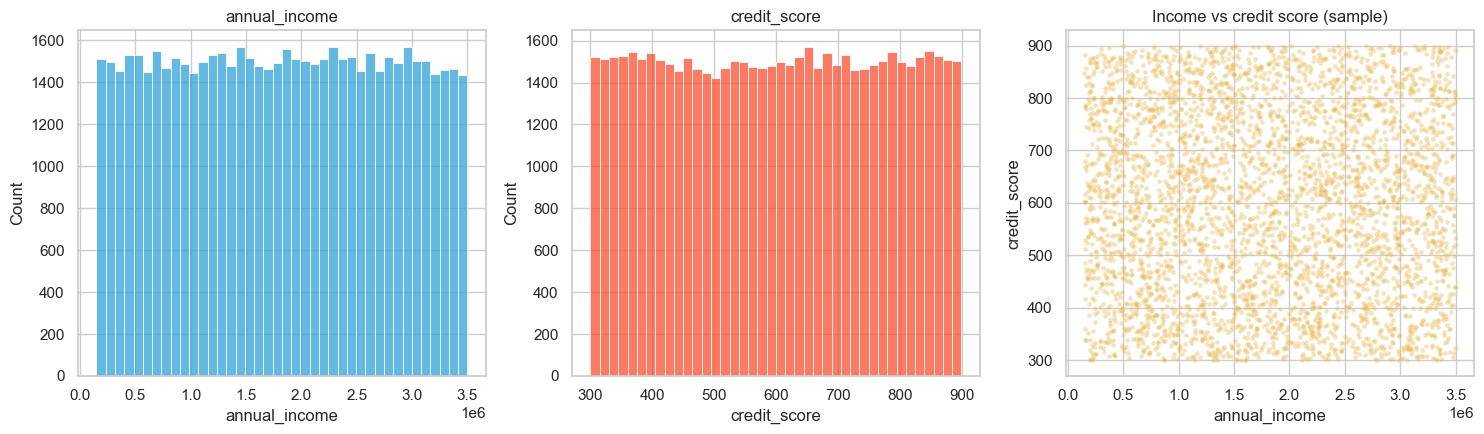

,mean,median,count
account_type,,,
Current,45744.84,31809.15,19021
Fixed Deposit,45019.02,30525.46,9458
NRI,46657.61,32579.06,4694
Salary,45193.94,31545.96,14270
Savings,45997.15,31971.99,47557


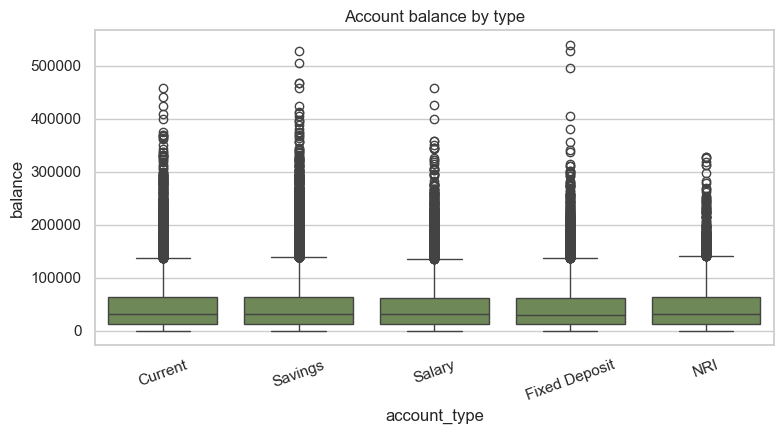

In [4]:
# --- Income breakdown ---
assert customers["annual_income"].notna().all()
assert customers["credit_score"].notna().all()
assert customers["occupation"].notna().all()

income_desc = customers["annual_income"].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9])
print("annual_income summary")
display(income_desc.to_frame("annual_income").T.round(0))

customers = customers.copy()
customers["income_quintile"] = pd.qcut(
    customers["annual_income"], 5, labels=["Q1 (low)", "Q2", "Q3", "Q4", "Q5 (high)"]
)
income_band = (
    customers.groupby("income_quintile", observed=True)["annual_income"]
    .agg(n="count", min="min", median="median", mean="mean", max="max")
    .round(0)
)
print("Income quintile bands")
display(income_band)

f, ax = plt.subplots(1, 2, figsize=(13, 4.5))
sns.histplot(customers["annual_income"], bins=40, ax=ax[0], color="#30a2da")
ax[0].set_title("annual_income distribution")
sns.countplot(data=customers, x="income_quintile", ax=ax[1], color="#30a2da", order=income_band.index)
ax[1].set_title("Customers per income quintile")
ax[1].tick_params(axis="x", rotation=15)
plt.tight_layout()
plt.show()

# --- Income × credit score ---
pearson_r, pearson_p = stats.pearsonr(customers["annual_income"], customers["credit_score"])
spearman_r, spearman_p = stats.spearmanr(customers["annual_income"], customers["credit_score"])
print(
    f"Income ↔ credit_score | Pearson r={pearson_r:.4f} (p={pearson_p:.3g}) | "
    f"Spearman ρ={spearman_r:.4f} (p={spearman_p:.3g})"
)

credit_by_income = (
    customers.groupby("income_quintile", observed=True)["credit_score"]
    .agg(n="count", mean="mean", median="median", std="std")
    .round(2)
)
print("Credit score by income quintile")
display(credit_by_income)

f, ax = plt.subplots(1, 3, figsize=(15, 4.5))
sns.histplot(customers["credit_score"], bins=40, ax=ax[0], color="#fc4f30")
ax[0].set_title("credit_score distribution")
sns.boxplot(
    data=customers, x="income_quintile", y="credit_score",
    ax=ax[1], color="#fc4f30", order=income_band.index,
)
ax[1].set_title("Credit score by income quintile")
ax[1].tick_params(axis="x", rotation=15)
sns.scatterplot(
    data=customers.sample(4000, random_state=7),
    x="annual_income", y="credit_score", ax=ax[2], alpha=0.35, s=12, color="#e5ae38",
)
ax[2].set_title("Income vs credit score (sample)")
plt.tight_layout()
plt.show()

# --- Occupation as third factor ---
occ_order = (
    customers.groupby("occupation")["annual_income"].median().sort_values(ascending=False).index.tolist()
)
occ_summary = (
    customers.groupby("occupation")
    .agg(
        n=("customer_id", "count"),
        income_median=("annual_income", "median"),
        income_mean=("annual_income", "mean"),
        credit_median=("credit_score", "median"),
        credit_mean=("credit_score", "mean"),
        income_credit_r=("annual_income", lambda s: s.corr(customers.loc[s.index, "credit_score"])),
    )
    .reindex(occ_order)
    .round(3)
)
print("Occupation × income × credit")
display(occ_summary)

f, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(
    data=customers, x="occupation", y="annual_income",
    order=occ_order, ax=ax[0], color="#30a2da",
)
ax[0].set_title("Income by occupation")
ax[0].tick_params(axis="x", rotation=25)
sns.boxplot(
    data=customers, x="occupation", y="credit_score",
    order=occ_order, ax=ax[1], color="#fc4f30",
)
ax[1].set_title("Credit score by occupation")
ax[1].tick_params(axis="x", rotation=25)
plt.tight_layout()
plt.show()

# Mean credit score: occupation × income quintile
occ_income_credit = (
    customers.groupby(["occupation", "income_quintile"], observed=True)["credit_score"]
    .mean()
    .unstack()
    .reindex(index=occ_order, columns=income_band.index)
)
f, ax = plt.subplots(figsize=(10, 5.5))
sns.heatmap(
    occ_income_credit, annot=True, fmt=".1f", cmap="YlOrRd", ax=ax,
    cbar_kws={"label": "mean credit_score"},
)
ax.set_title("Mean credit score — occupation × income quintile")
ax.set_xlabel("income_quintile")
ax.set_ylabel("occupation")
plt.tight_layout()
plt.show()
display(occ_income_credit.round(1))

# Sample scatter: income vs credit, colored by occupation
f, ax = plt.subplots(figsize=(10, 5.5))
sns.scatterplot(
    data=customers.sample(5000, random_state=7),
    x="annual_income", y="credit_score", hue="occupation",
    hue_order=occ_order, ax=ax, alpha=0.45, s=18,
)
ax.set_title("Income vs credit score by occupation (sample)")
ax.legend(title="occupation", bbox_to_anchor=(1.02, 0.5), loc="center left", fontsize=8)
plt.tight_layout()
plt.show()

# Account product mix (unchanged companion view)
acct_cust = accounts.merge(
    customers[["customer_id", "credit_score", "annual_income", "state", "occupation"]],
    on="customer_id",
)
display(acct_cust.groupby("account_type")["balance"].agg(["mean", "median", "count"]).round(2))
f, ax = plt.subplots(figsize=(8, 4.5))
sns.boxplot(data=acct_cust, x="account_type", y="balance", ax=ax, color="#6d904f")
ax.set_title("Account balance by type")
ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()


**How to Interpret:** <br>
Income is spread wide (~150k–3.5M) with near-equal quintile counts by construction of `qcut`. The headline association check is income ↔ credit: Pearson/Spearman near zero means the generator did **not** wire higher earners to better scores. Quintile boxplots and the occupation×income heatmap stay flat around ~600 — occupation labels also do not shift income or credit medians in a meaningful way. Treat income, credit, and occupation as almost independent customer attributes here, not a real underwriting stack. Account-type balance boxes remain the product-mix view; extreme balances may be generator tails rather than realistic VIP accounts.


# **4. Loans and Late Payments:** <a id="Loans"></a>


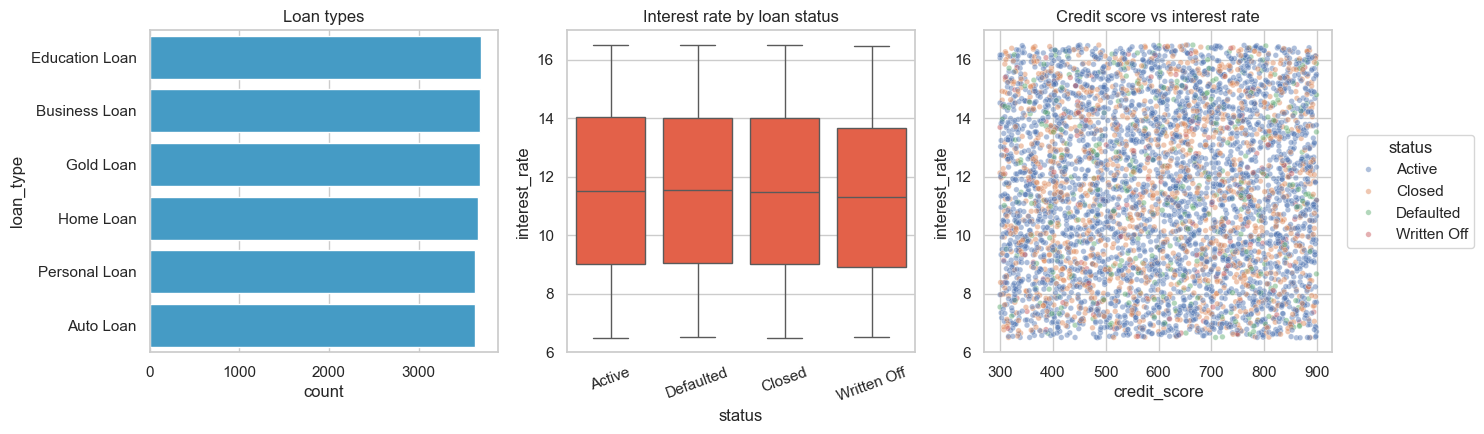

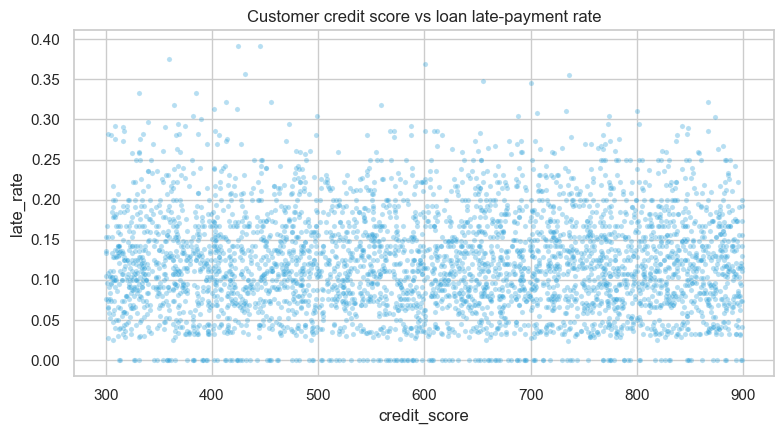

Mean late_payment_flag: 0.1201


In [5]:
loan_cust = loans.merge(
    customers[["customer_id", "credit_score", "annual_income", "occupation"]],
    on="customer_id", how="left",
)
assert loan_cust["credit_score"].notna().all()

f, ax = plt.subplots(1, 3, figsize=(15, 4.5))
sns.countplot(data=loan_cust, y="loan_type", order=loan_cust["loan_type"].value_counts().index, ax=ax[0], color="#30a2da")
ax[0].set_title("Loan types")
sns.boxplot(data=loan_cust, x="status", y="interest_rate", ax=ax[1], color="#fc4f30")
ax[1].set_title("Interest rate by loan status")
ax[1].tick_params(axis="x", rotation=20)
sns.scatterplot(
    data=loan_cust.sample(min(5000, len(loan_cust)), random_state=7),
    x="credit_score", y="interest_rate", hue="status", ax=ax[2], alpha=0.45, s=16,
)
ax[2].set_title("Credit score vs interest rate")
ax[2].legend(title="status", bbox_to_anchor=(1.02, 0.5), loc="center left")
plt.tight_layout()
plt.show()

late_rate = loan_payments.groupby("loan_id")["late_payment_flag"].mean().rename("late_rate")
loan_risk = loan_cust.merge(late_rate, on="loan_id", how="left")
assert loan_risk["late_rate"].notna().mean() > 0.5
f, ax = plt.subplots(figsize=(8, 4.5))
sns.scatterplot(
    data=loan_risk.sample(min(4000, len(loan_risk)), random_state=7),
    x="credit_score", y="late_rate", alpha=0.35, s=14, color="#30a2da", ax=ax,
)
ax.set_title("Customer credit score vs loan late-payment rate")
plt.tight_layout()
plt.show()
print("Mean late_payment_flag:", round(loan_payments["late_payment_flag"].mean(), 4))


**How to Interpret:** <br>
Interest rate by status and credit score asks whether risk pricing is coherent in the generator. Late-payment rates aggregated to `loan_id` are a simple delinquency proxy — not a legal default definition.


# **5. Support Tickets:** <a id="Tickets"></a>


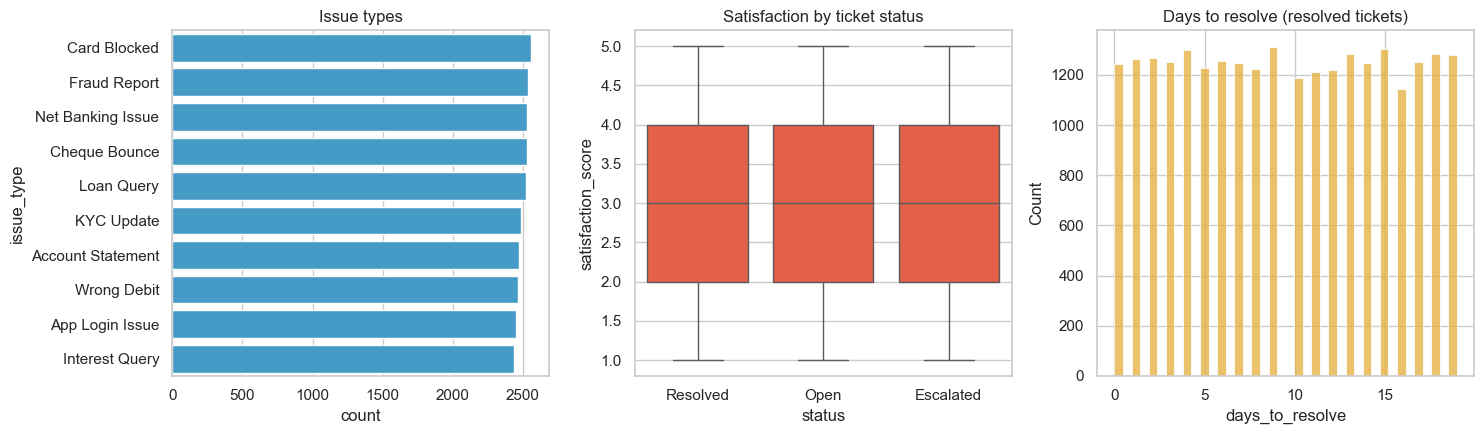

Share of customers with >=1 ticket: 0.342


,mean,count
issue_type,,
Account Statement,2.97,2474
Cheque Bounce,2.97,2531
Wrong Debit,2.97,2466
Interest Query,2.99,2440
KYC Update,3.00,2491
Fraud Report,3.01,2535
Card Blocked,3.01,2560
Net Banking Issue,3.03,2532
Loan Query,3.04,2521


In [6]:
tickets["date_opened"] = pd.to_datetime(tickets["date_opened"], errors="coerce")
tickets["date_resolved"] = pd.to_datetime(tickets["date_resolved"], errors="coerce")
resolved = tickets.dropna(subset=["date_opened", "date_resolved"]).copy()
resolved["days_to_resolve"] = (resolved["date_resolved"] - resolved["date_opened"]).dt.days
assert (resolved["days_to_resolve"] >= 0).all()

f, ax = plt.subplots(1, 3, figsize=(15, 4.5))
sns.countplot(
    data=tickets, y="issue_type",
    order=tickets["issue_type"].value_counts().index, ax=ax[0], color="#30a2da",
)
ax[0].set_title("Issue types")
sns.boxplot(data=tickets, x="status", y="satisfaction_score", ax=ax[1], color="#fc4f30")
ax[1].set_title("Satisfaction by ticket status")
sns.histplot(resolved["days_to_resolve"], bins=40, ax=ax[2], color="#e5ae38")
ax[2].set_title("Days to resolve (resolved tickets)")
plt.tight_layout()
plt.show()

ticket_rate = tickets.groupby("customer_id").size().rename("n_tickets")
cust_t = customers.merge(ticket_rate, on="customer_id", how="left")
cust_t["n_tickets"] = cust_t["n_tickets"].fillna(0).astype(int)
print("Share of customers with >=1 ticket:", round((cust_t["n_tickets"] > 0).mean(), 3))
display(
    tickets.groupby("issue_type")["satisfaction_score"]
    .agg(["mean", "count"])
    .sort_values("mean")
    .round(2)
    .head(12)
)


**How to Interpret:** <br>
Issue-type mix and satisfaction by status are service-quality views. Days-to-resolve on resolved tickets only — open tickets are excluded rather than imputed.


# **6. Sampled Transactions & Card Fraud:** <a id="Fraud"></a>


transactions path: /Users/nicapotato/.cache/kagglehub/datasets/vivekmali1436/banking-transactions-dataset/versions/1/transactions.csv
card_transactions path: /Users/nicapotato/.cache/kagglehub/datasets/vivekmali1436/banking-transactions-dataset/versions/1/card_transactions.csv


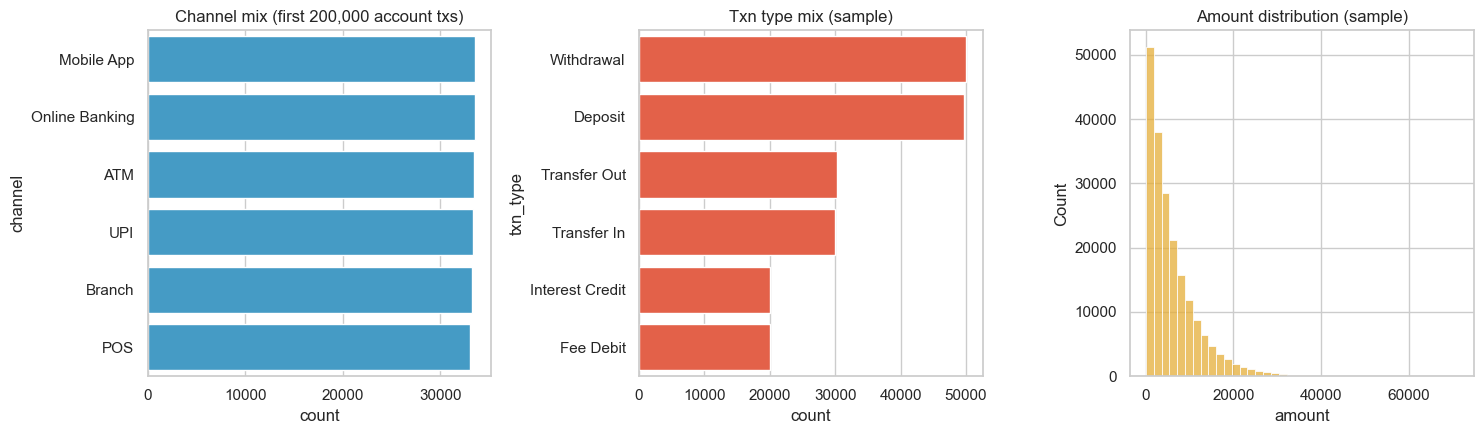

Global card fraud rate (full file chunks): 0.4985% over 3,000,000 rows


,fraud,n,rate
ATM Withdrawal,1121,214289,0.0052
Healthcare,1119,214975,0.0052
Salary Credit,1115,214558,0.0052
Entertainment,1096,213605,0.0051
Fuel,1076,214392,0.0050
Utilities,1069,214654,0.0050
Groceries,1065,214009,0.0050
Fund Transfer,1067,214964,0.0050
Dining,1057,214599,0.0049
Rent,1046,213915,0.0049


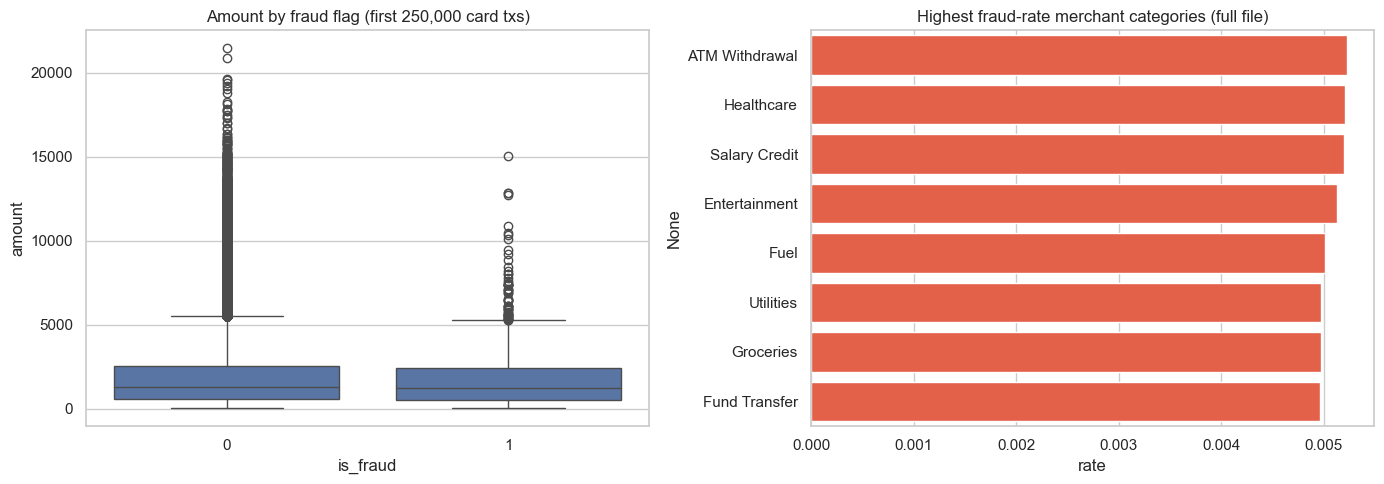

In [7]:
tx_path = list(Path(root).rglob("transactions.csv"))[0]
card_path = list(Path(root).rglob("card_transactions.csv"))[0]
print("transactions path:", tx_path)
print("card_transactions path:", card_path)

tx = pd.read_csv(tx_path, nrows=TX_SAMPLE_N, low_memory=False)
card_tx = pd.read_csv(card_path, nrows=CARD_SAMPLE_N, low_memory=False)
assert {"amount", "channel", "merchant_category", "txn_type"}.issubset(tx.columns)
assert {"amount", "merchant_category", "is_fraud"}.issubset(card_tx.columns)
assert card_tx["is_fraud"].isin([0, 1]).all()

f, ax = plt.subplots(1, 3, figsize=(15, 4.5))
sns.countplot(data=tx, y="channel", order=tx["channel"].value_counts().index, ax=ax[0], color="#30a2da")
ax[0].set_title(f"Channel mix (first {TX_SAMPLE_N:,} account txs)")
sns.countplot(data=tx, y="txn_type", order=tx["txn_type"].value_counts().index, ax=ax[1], color="#fc4f30")
ax[1].set_title("Txn type mix (sample)")
sns.histplot(tx["amount"], bins=40, ax=ax[2], color="#e5ae38")
ax[2].set_title("Amount distribution (sample)")
plt.tight_layout()
plt.show()

# Chunked global fraud rate + category rates (does not keep full frame)
fraud_num = 0
fraud_den = 0
cat_fraud = {}
cat_n = {}
for chunk in pd.read_csv(card_path, usecols=["merchant_category", "is_fraud"], chunksize=400_000):
    fraud_num += int(chunk["is_fraud"].sum())
    fraud_den += len(chunk)
    g = chunk.groupby("merchant_category")["is_fraud"].agg(["sum", "count"])
    for cat, row in g.iterrows():
        cat_fraud[cat] = cat_fraud.get(cat, 0) + int(row["sum"])
        cat_n[cat] = cat_n.get(cat, 0) + int(row["count"])
assert fraud_den > 0
global_fraud = fraud_num / fraud_den
print(f"Global card fraud rate (full file chunks): {global_fraud:.4%} over {fraud_den:,} rows")

cat_rates = (
    pd.DataFrame({"fraud": cat_fraud, "n": cat_n})
    .assign(rate=lambda d: d["fraud"] / d["n"])
    .sort_values("rate", ascending=False)
)
display(cat_rates.head(12).round(4))

f, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(
    data=card_tx, x="is_fraud", y="amount", ax=ax[0],
)
ax[0].set_title(f"Amount by fraud flag (first {CARD_SAMPLE_N:,} card txs)")
top_cats = cat_rates.head(8).index
sns.barplot(x=cat_rates.loc[top_cats, "rate"], y=top_cats, ax=ax[1], color="#fc4f30")
ax[1].set_title("Highest fraud-rate merchant categories (full file)")
plt.tight_layout()
plt.show()


**How to Interpret:** <br>
Account-tx plots use a head sample — good for channel/type mix shape, not for rare-event rates. Fraud rates use a full chunked pass so the global rate and category ranking are file-complete. Amount-by-fraud boxes still use the sample for speed.


# **7. What It Means — Working Synthesis:** <a id="Synthesis"></a>

**What the table is:** <br>
A synthetic multi-table banking warehouse for SQL/BI/ML practice, with million-row payment and card facts.

**Working takeaways:** <br>
- On the customer table alone, income, credit score, and occupation are nearly independent (≈0 Pearson/Spearman; flat occupation×income credit heatmap) — a synthetic-generator tell, not a real underwriting curve.
- Credit/income still join cleanly to loans and late-payment proxies in later sections.
- Tickets give a service layer (issue type, satisfaction, resolve time).
- Fraud analysis needs chunked aggregates; do not treat head samples as population rates.

**Open follow-ups:** <br>
- Customer-level feature store joining tickets + loan delinquency + card fraud.
- Branch-level portfolio heatmaps (loan volume × late rate).
